In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import shutil
from tensorflow import keras
from keras.preprocessing import image
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from keras.utils import load_img, img_to_array
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

2026-02-24 00:14:49.811822: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 00:14:49.956043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 00:14:57.200322: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 00:15:31.309384: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
src_dir = "/workspaces/AnthonnyMal-Machine-Learnig/data/raw/dogs-vs-cats/dogs-vs-cats/train"

dest_dir = "/workspaces/AnthonnyMal-machine-learning/data/processed/dogs-vs-cats"

train_cats = os.path.join(dest_dir, "train", "cats")
train_dogs = os.path.join(dest_dir, "train", "dogs")
test_cats  = os.path.join(dest_dir, "test", "cats")
test_dogs  = os.path.join(dest_dir, "test", "dogs")

for folder in [train_cats, train_dogs, test_cats, test_dogs]:
    os.makedirs(folder, exist_ok=True)


all_images = [f for f in os.listdir(src_dir) if f.lower().endswith(".jpg")]
cat_images = [f for f in all_images if f.lower().startswith("cat.")]
dog_images = [f for f in all_images if f.lower().startswith("dog.")]

print("\nTotal gatos:", len(cat_images))
print("Total perros:", len(dog_images), "\n")

def split_and_copy(files, src, train_path, test_path, train_ratio=0.8):
    random.shuffle(files)
    split_idx = int(len(files) * train_ratio)

    train_files = files[:split_idx]
    test_files  = files[split_idx:]

    for f in train_files:
        shutil.copy2(os.path.join(src, f), os.path.join(train_path, f))

    for f in test_files:
        shutil.copy2(os.path.join(src, f), os.path.join(test_path, f))

    print(f"{train_path}: {len(train_files)} train")
    print(f"{test_path}:  {len(test_files)} test\n")

split_and_copy(cat_images, src_dir, train_cats, test_cats)
split_and_copy(dog_images, src_dir, train_dogs, test_dogs)



Total gatos: 12500
Total perros: 12500 

/workspaces/AnthonnyMal-machine-learning/data/processed/dogs-vs-cats/train/cats: 10000 train
/workspaces/AnthonnyMal-machine-learning/data/processed/dogs-vs-cats/test/cats:  2500 test

/workspaces/AnthonnyMal-machine-learning/data/processed/dogs-vs-cats/train/dogs: 10000 train
/workspaces/AnthonnyMal-machine-learning/data/processed/dogs-vs-cats/test/dogs:  2500 test



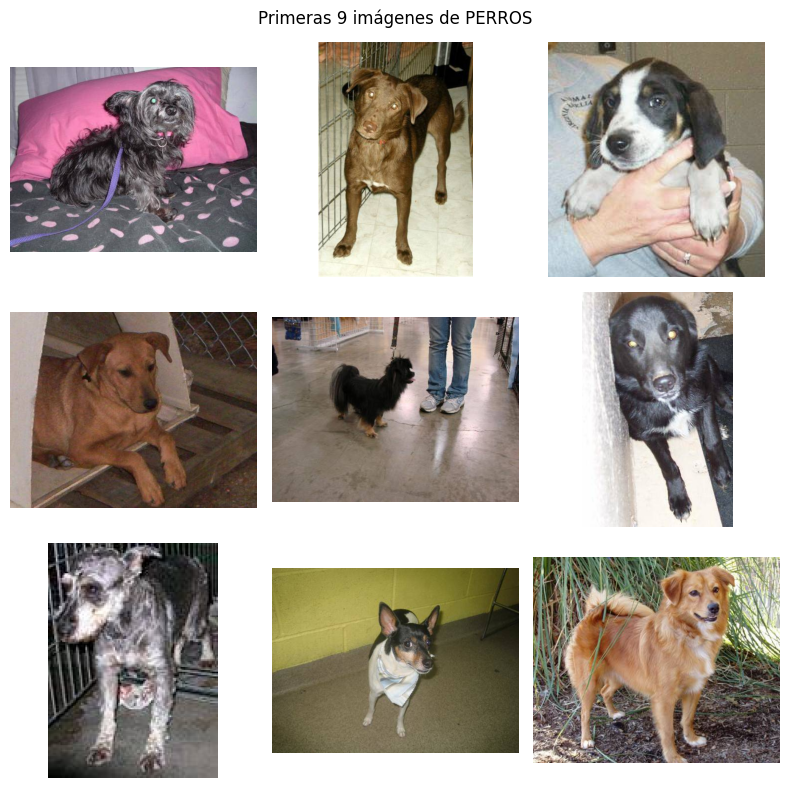

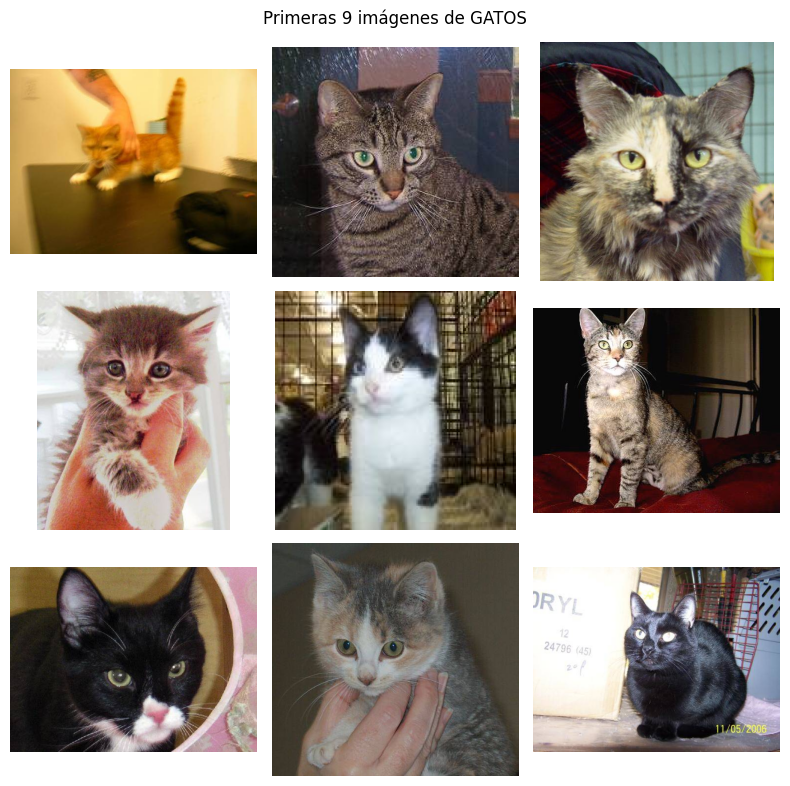

In [3]:
train_dir = "../data/processed/dogs-vs-cats/train"
test_dir  = "../data/processed/dogs-vs-cats/test"

cats_dir = os.path.join(train_dir, "cat")
dogs_dir = os.path.join(train_dir, "dog")

def show_examples(folder, title, n=9):

    images = sorted([f for f in os.listdir(folder) if f.lower().endswith((".jpg",".jpeg",".png"))])[:n]

    plt.figure(figsize=(8, 8))
    plt.suptitle(title)

    for i, img in enumerate(images):
        img_path = os.path.join(folder, img)
        im = Image.open(img_path)

        plt.subplot(3, 3, i+1)
        plt.imshow(im)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_examples(dogs_dir, "Primeras 9 imágenes de PERROS")
show_examples(cats_dir, "Primeras 9 imágenes de GATOS")

In [4]:
IMG_SIZE = (200, 200)
BATCH = 32

base_dir = "../data/processed/dogs-vs-cats"
train_dir = os.path.join(base_dir, "train")

print("train_dir:", os.path.abspath(train_dir), "| existe?:", os.path.isdir(train_dir), "| clases:", os.listdir(train_dir))

trdata = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = trdata.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

val_data = trdata.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

print("class_indices:", train_data.class_indices)

train_dir: /workspaces/AnthonnyMal-Machine-Learnig/data/processed/dogs-vs-cats/train | existe?: True | clases: ['dog', 'cat']
Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
class_indices: {'cat': 0, 'dog': 1}


In [5]:
IMG_SIZE = (200, 200)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Entrenamiento con tu validación (val_data)
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

/home/vscode/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-24 00:17:39.272808: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    18,874,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,894,017 (72.07 MB)

 Trainable params: 18,894,017 (72.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 436s 683ms/step - accuracy: 0.6385 - loss: 0.6681 - val_accuracy: 0.6868 - val_loss: 0.5818
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 414s 663ms/step - accuracy: 0.7596 - loss: 0.5017 - val_accuracy: 0.7724 - val_loss: 0.4838
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 417s 668ms/step - accuracy: 0.8231 - loss: 0.3920 - val_accuracy: 0.7614 - val_loss: 0.4972
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 416s 665ms/step - accuracy: 0.8878 - loss: 0.2732 - val_accuracy: 0.7656 - val_loss: 0.5359
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 419s 670ms/step - accuracy: 0.9362 - loss: 0.1657 - val_accuracy: 0.7626 - val_loss: 0.6663


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


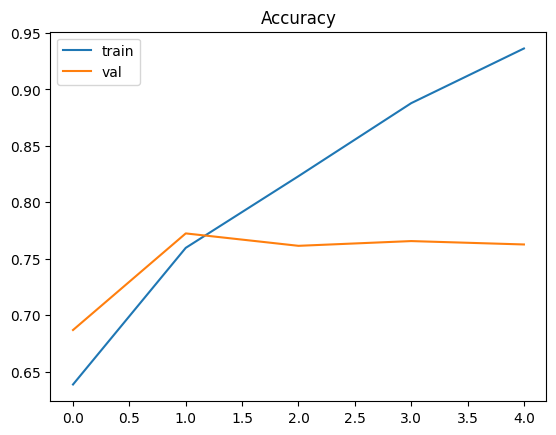

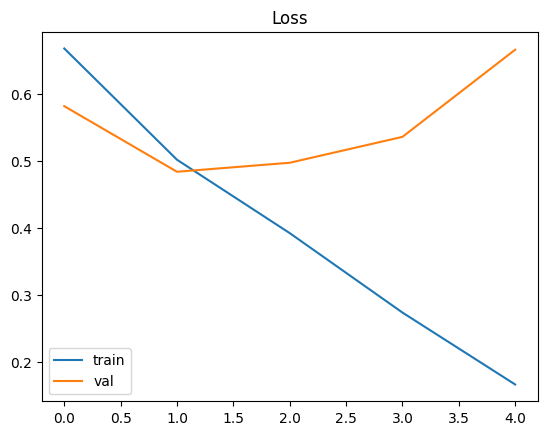

In [ ]:
# Accuracy
plt.plot(history.history.get("accuracy", history.history.get("acc")))
plt.plot(history.history.get("val_accuracy", history.history.get("val_acc")))
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

# Loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [12]:
val_loss, val_acc = model.evaluate(val_data)

# model.save("../models/dogs_vs_cats_cnn.h5")
# No pudimos cargar el modelo por que pesa mucho para nuestro repositorio, lo dejaremos comentado.

157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 193ms/step - accuracy: 0.7724 - loss: 0.4838
